In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
plt.style.use('seaborn-v0_8')

In [3]:
data = pd.read_csv('smaller.csv', dtype={'SOCP': str})
data['inc2024'] = data.PINCP * data.ADJINC / 1_000_000
print(data.shape, data.PWGTP.sum())

data = data.dropna(subset=['PWGTP', 'ADJINC', 'PINCP'])
print(data.shape, data.PWGTP.sum())

data = data[data.inc2024 > 0]
print(data.shape, data.PWGTP.sum())

(3422888, 7) 340110990
(2912790, 7) 280613270
(2556439, 7) 245168158


In [6]:
data.sort_values('inc2024', inplace=True)

In [9]:
data['inc_cum'] = (data.inc2024 * data.PWGTP).cumsum()

In [14]:
rng = np.random.default_rng(seed=42)
data['random'] = rng.random(len(data))

In [42]:
sample = data.sample(n=245*5, weights='PWGTP', random_state=10)

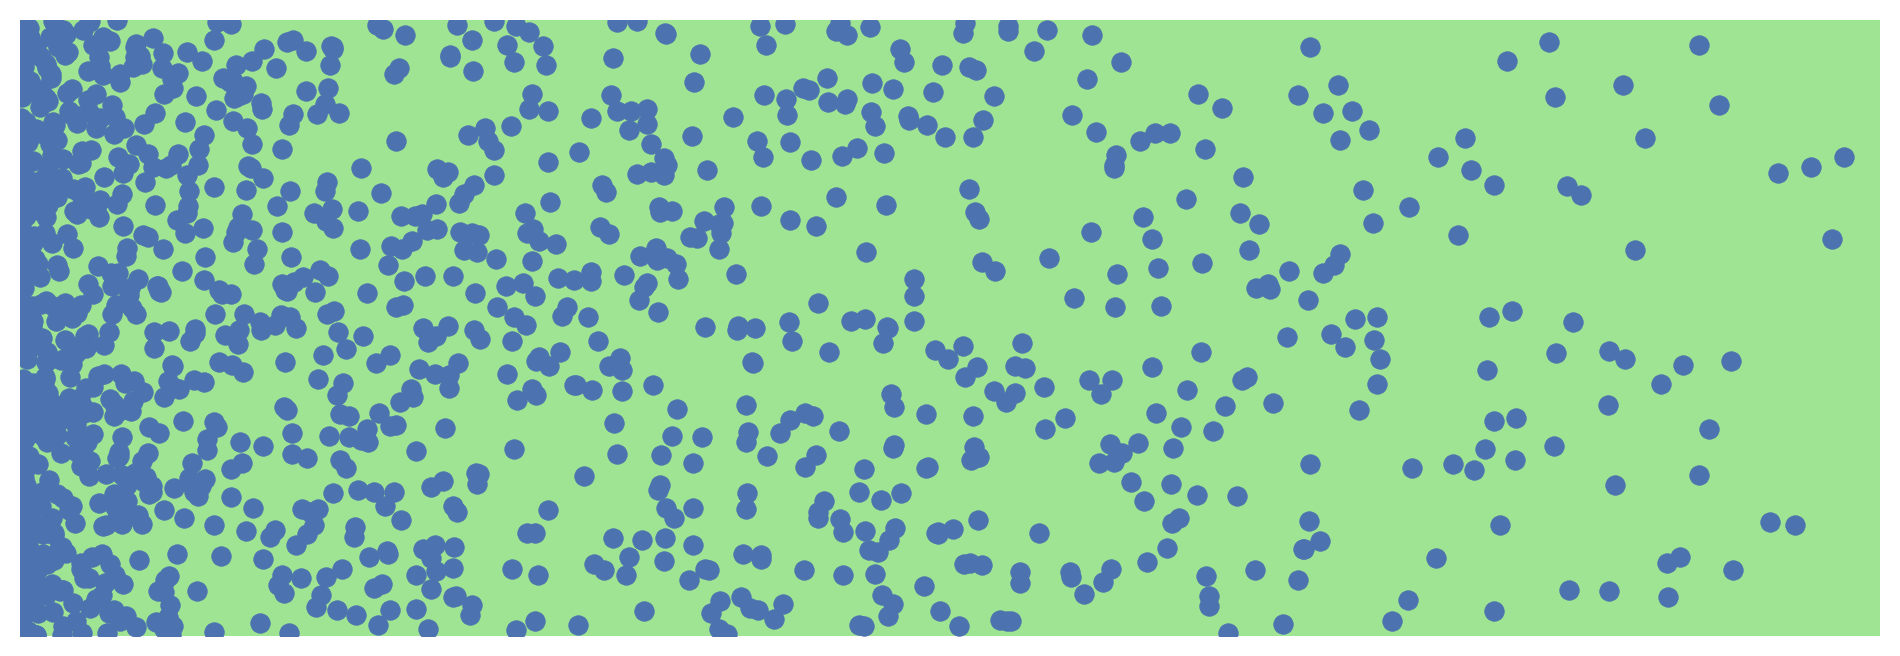

In [43]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_facecolor('#9ee493')
ax.tick_params(left=False, bottom=False)
ax.set_yticks([]) 
ax.set_xticks([]) 
ax.xaxis.set_tick_params(labelbottom=True)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.ylim(0,1)
plt.xlim(0, data.inc_cum.max())
plt.scatter(x=sample.inc_cum, y=sample.random)#, marker='$⚇$')
plt.show()

In [44]:
rng = np.random.default_rng(seed=43)
data['random'] = rng.random(len(data))
sample = data.sample(n=245*5, weights='PWGTP', random_state=11)

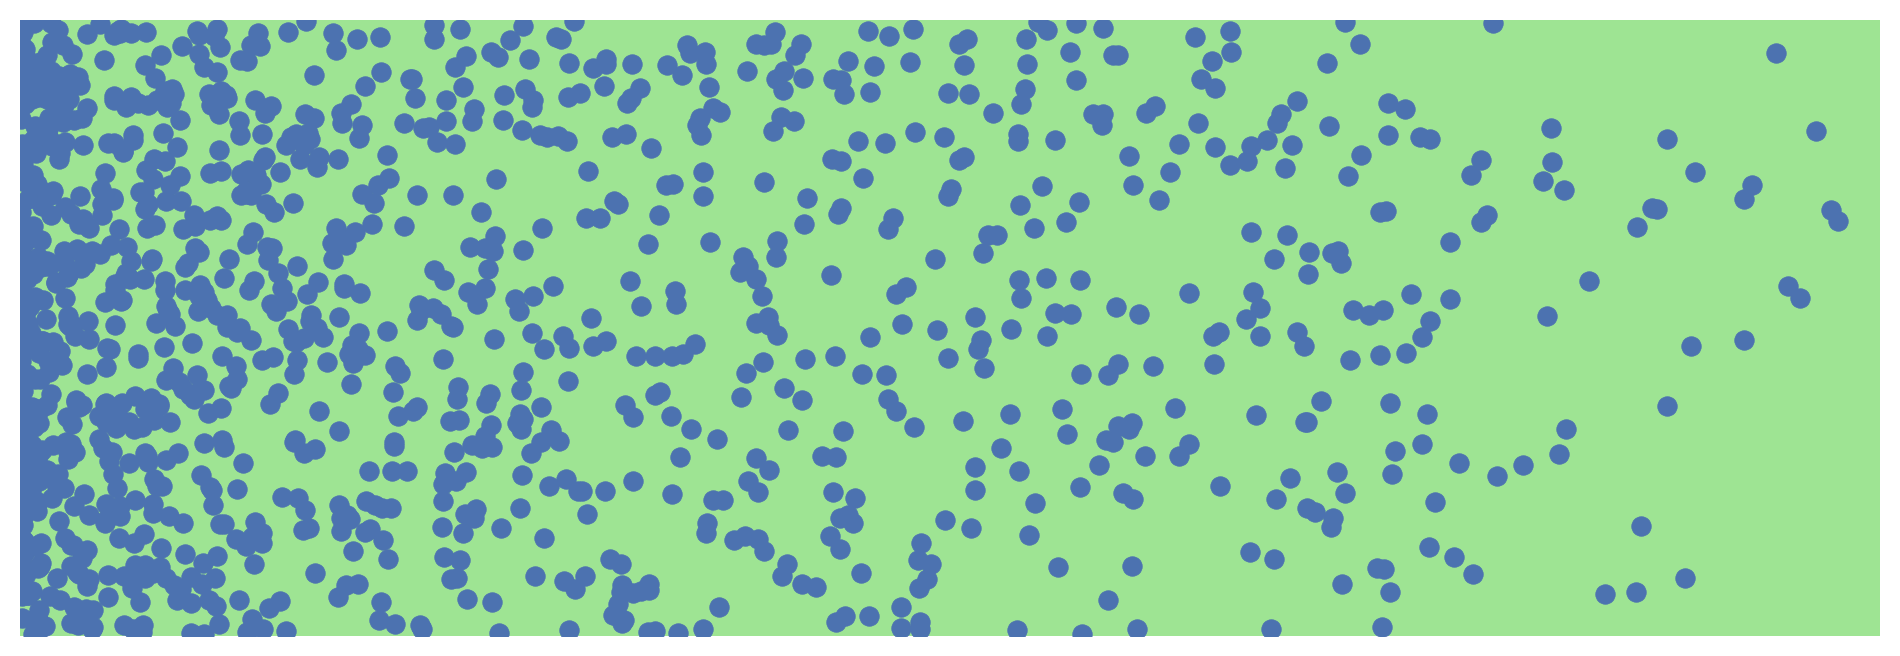

In [45]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_facecolor('#9ee493')
ax.tick_params(left=False, bottom=False)
ax.set_yticks([]) 
ax.set_xticks([]) 
ax.xaxis.set_tick_params(labelbottom=True)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.ylim(0,1)
plt.xlim(0, data.inc_cum.max())
plt.scatter(x=sample.inc_cum, y=sample.random)#, marker='$⚇$')
plt.show()

In [58]:
target_values = [50_000, 100_000, 200_000]
inc_cum_values = [data.loc[data['inc2024'] >= target_value, :].iloc[0].inc_cum for target_value in target_values]
print(data.inc2024.max())

1974661.25


In [71]:
total = data.PWGTP.sum()
print(f'{total=}')
print(data.PWGTP[data.inc2024 < 50_000].sum() / total) # 57%
print(data.PWGTP[(50_000 <= data.inc2024) & (data.inc2024 < 100_000)].sum() / total)  # 27%
print(data.PWGTP[(100_000 <= data.inc2024) & (data.inc2024 < 200_000)].sum() / total)  # 12%
print(data.PWGTP[200_000 <= data.inc2024].sum() / total)  # 4%

total=np.int64(245168158)
0.5680223244977841
0.2671244852278084
0.12177162500849723
0.04308156526591027


In [78]:
total = (data.PWGTP * data.inc2024).sum()
print(f'{total=}')
print((data.PWGTP * data.inc2024)[data.inc2024 < 50_000].sum() / total) # 21%
print((data.PWGTP * data.inc2024)[(50_000 <= data.inc2024) & (data.inc2024 < 100_000)].sum() / total)  # 29%
print((data.PWGTP * data.inc2024)[(100_000 <= data.inc2024) & (data.inc2024 < 200_000)].sum() / total)  # 26%
print((data.PWGTP * data.inc2024)[200_000 <= data.inc2024].sum() / total)  # 24%

total=np.float64(15408604191922.902)
0.2061858077468886
0.29615270506041314
0.2568998830200765
0.24076160417262185


In [75]:
sample.shape, 245168158 / 1225

((1225, 9), 200137.2718367347)

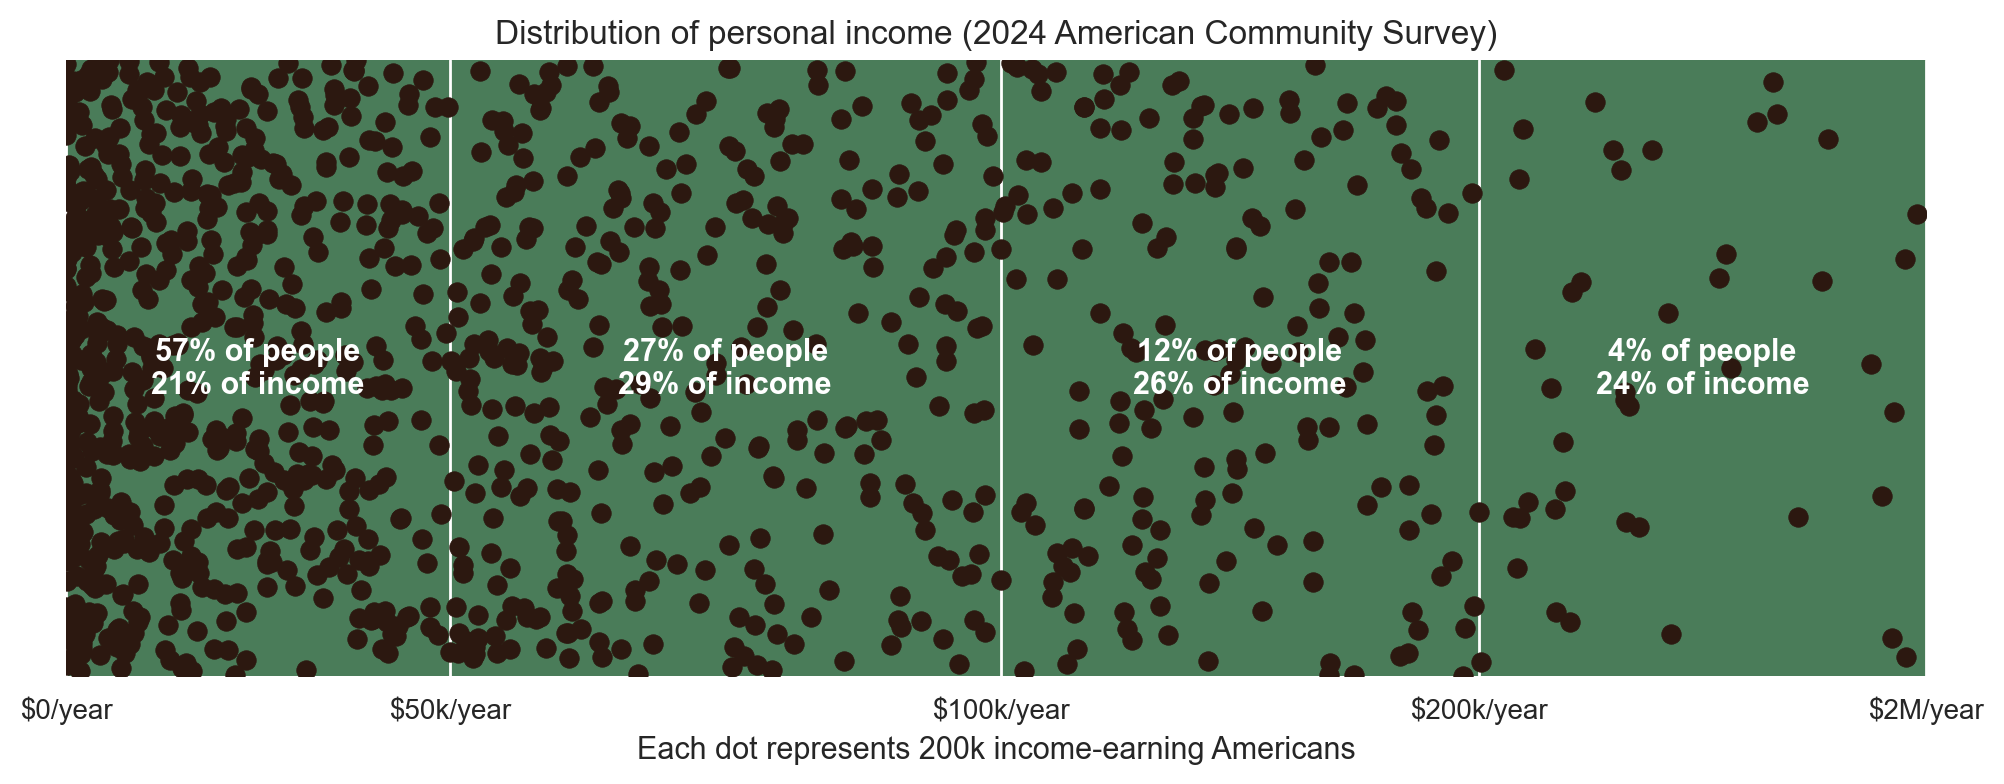

In [96]:
rng = np.random.default_rng(seed=44)
data['random'] = rng.random(len(data))
sample = data.sample(n=245*5, weights='PWGTP', random_state=12)

fig, ax = plt.subplots(figsize=(12, 4))
#ax.set_facecolor('#85bb65')
ax.set_facecolor('#4a7c59')
#ax.set_facecolor('#9ee493')
ax.tick_params(left=False, bottom=False)
ax.set_yticks([])
ax.set_xticks([])
ax.xaxis.set_tick_params(labelbottom=True)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.ylim(0,1)
plt.xlim(0, data.inc_cum.max())
plt.scatter(x=sample.inc_cum, y=sample.random, color='#2c1810')

plt.xticks([0] + inc_cum_values + [data.inc_cum.max()], ['$0/year', '$50k/year', '$100k/year', '$200k/year', '$2M/year'])
plt.xlabel('Each dot represents 200k income-earning Americans')

ax.text(
    x=(0 + inc_cum_values[0]) / 2,           # centered between two x points
    y=ax.get_ylim()[1] / 2,     # centered vertically
    s='57% of people\n21% of income',
    ha='center', va='center',
    color='white', fontsize=11, fontweight='bold'
)

ax.text(
    x=(inc_cum_values[0] + inc_cum_values[1]) / 2,           # centered between two x points
    y=ax.get_ylim()[1] / 2,     # centered vertically
    s='27% of people\n29% of income',
    ha='center', va='center',
    color='white', fontsize=11, fontweight='bold'
)

ax.text(
    x=(inc_cum_values[1] + inc_cum_values[2]) / 2,           # centered between two x points
    y=ax.get_ylim()[1] / 2,     # centered vertically
    s='12% of people\n26% of income',
    ha='center', va='center',
    color='white', fontsize=11, fontweight='bold'
)

ax.text(
    x=(inc_cum_values[2] + data.inc_cum.max()) / 2,           # centered between two x points
    y=ax.get_ylim()[1] / 2,     # centered vertically
    s='4% of people\n24% of income',
    ha='center', va='center',
    color='white', fontsize=11, fontweight='bold'
)

plt.title('Distribution of personal income (2024 American Community Survey)')

plt.show()